In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Architecture

$$MSE\left(m_{1} , m_{2},...., b\right) = \frac{1}{2n}\sum_{i=1}^{n} \left(\hat{y} - y\right)^2 =
\frac{1}{2n}\sum_{i=1}^{n} \left(m_{1}x_{1} + m_{2} x_{2} +.....+b - y\right)^2\tag{1}$$
_
\begin{align}
\frac{\partial E }{ \partial m_{(i)} } &=
\frac{1}{n}\sum_{i=1}^{n} \left(m_{(i)}x_{(i)}+b - y_{(i)}\right)x_{(i)},\\
\frac{\partial E }{ \partial b } &=
\frac{1}{n}\sum_{i=1}^{n} \left(m_{(i)}x_{(i)}+b - y_{(i)}\right) \cdot 1,
\tag{2}\end{align}
notice that the gradient for $ \left( m_{(i)} \right) $ and $ \left( b \right) $ are similar but instead of multipling by the Feature column we multiply by one
**so we add ones columns with the features** and that helps model to act as a Simple Linear Regression and also Multiple Linear Regression.
So from **(1)** and **(2)**, we can derive the general gradient vector as
$$W = \begin{bmatrix}
b \\
m_1 \\
m_2 \\
\vdots \\
m_k
\end{bmatrix}$$
and update the parameters iteratively using the expressions
$$\begin{equation}
W = W - \alpha \frac{\partial E}{\partial W}
\end{equation}$$
$$\begin{equation}
W = \begin{bmatrix}
b \\
m_1 \\
m_2 \\
\vdots \\
m_k
\end{bmatrix} - \alpha . \begin{bmatrix}
\frac{\partial E }{ \partial b } \\
\frac{\partial E }{ \partial m_{(1)} } \\
\frac{\partial E }{ \partial m_{(2)} } \\
\vdots \\
\frac{\partial E }{ \partial m_{(k)} }
\end{bmatrix}
\end{equation}$$
and the prediction will be
\begin{equation}
\begin{bmatrix}
\hat{y}^{(1)} \\
\hat{y}^{(2)} \\
\vdots \\
\hat{y}^{(n)}
\end{bmatrix}
=
\begin{bmatrix}
1 & X_{1}^{(1)} & X_{2}^{(1)} & \cdots & X_{k}^{(1)} \\
1 & X_{1}^{(2)} & X_{2}^{(2)} & \cdots & X_{k}^{(2)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & X_{1}^{(n)} & X_{2}^{(n)} & \cdots & X_{k}^{(n)}
\end{bmatrix}
\begin{bmatrix}
b \\
m_1 \\
m_2 \\
\vdots \\
m_m
\end{bmatrix}
=
\begin{bmatrix}
1.b + m_1 X_{1}^{(1)} + m_2 X_{2}^{(1)} + \cdots + m_k X_{k}^{(1)} \\
1.b + m_1 X_{1}^{(2)} + m_2 X_{2}^{(2)} + \cdots + m_k X_{k}^{(2)} \\
\vdots \\
1.b + m_1 X_{1}^{(n)} + m_2 X_{2}^{(n)} + \cdots + m_k X_{k}^{(n)}
\end{bmatrix}
\end{equation}
all where $ \left( k \right) $ is the number of features $ \left( n \right) $ the number of samples

# Build the Model

#### Prediction

In [3]:
def predict (X , weights):
    return np.dot(X, weights)

#### Mean Square Error

In [4]:
def MSE(weights, X, Y):
    predictions = predict (X , weights)
    errors = predictions - Y
    return (1 / (2 * len(Y))) * np.sum(errors ** 2)

#### Gradient Descent

In [5]:
def gradient_descent(X, Y, learning_rate = 0.01, epochs = 1000):
    n = len(Y)
    weights = np.zeros(X.shape[1])
    for epoch in range(epochs):
        predictions = predict(X , weights)
        error = predictions - Y
        gradient = (1 / n) * np.dot(X.T, error)
        weights = weights - learning_rate * gradient
    return weights, MSE(weights, X, Y)

# Data Preprocessing

In [6]:
df = pd.read_csv("data/assignment1dataset.csv")
df = df.astype(float)
df.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
0,7063.0,76.0,10.0,29.84,2713.95
1,44372.0,66.0,45.0,16.72,5744.99
2,19255.0,37.0,17.0,14.30,4101.24
3,13265.0,14.0,41.0,32.82,3009.14
4,13375.0,26.0,18.0,11.92,3279.17


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Square Footage       1000 non-null   float64
 1   Number of Occupants  1000 non-null   float64
 2   Appliances Used      1000 non-null   float64
 3   Average Temperature  1000 non-null   float64
 4   Energy Consumption   1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


#### Calculated coulmn

In [8]:
df.insert(loc=len(df.columns) - 1, column='Appliances by Space', value= df['Square Footage'] * df['Appliances Used'])
df.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Appliances by Space,Energy Consumption
0,7063.0,76.0,10.0,29.84,70630.0,2713.95
1,44372.0,66.0,45.0,16.72,1996740.0,5744.99
2,19255.0,37.0,17.0,14.30,327335.0,4101.24
3,13265.0,14.0,41.0,32.82,543865.0,3009.14
4,13375.0,26.0,18.0,11.92,240750.0,3279.17


In [9]:
X_columns = df.columns[:-1]
Y_columns = df.columns[-1]
print(X_columns)
print(Y_columns)

Index(['Square Footage', 'Number of Occupants', 'Appliances Used',
       'Average Temperature', 'Appliances by Space'],
      dtype='str')
Energy Consumption


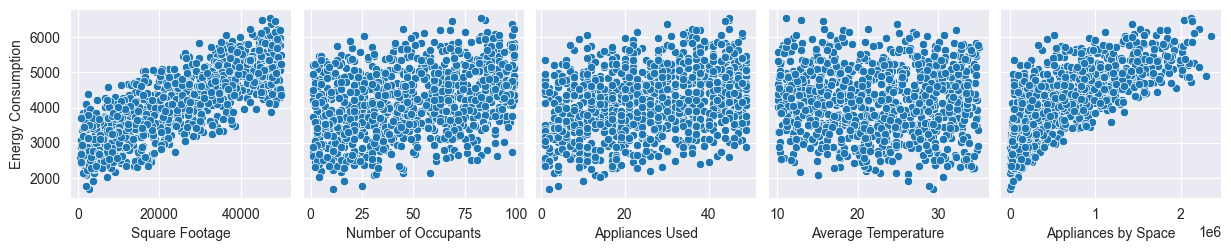

In [10]:
sns.pairplot(df, y_vars=Y_columns, x_vars=X_columns)

#### Noramlize Data

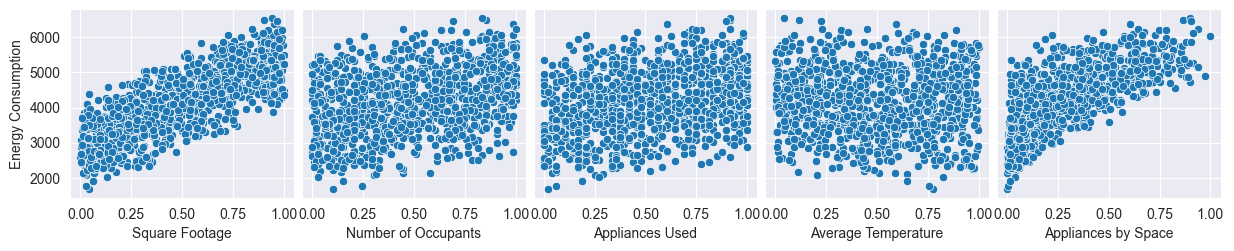

In [11]:
df[X_columns] = (df[X_columns] - df[X_columns].min()) / (df[X_columns].max() - df[X_columns].min())
sns.pairplot(df, y_vars=Y_columns, x_vars=X_columns)

#### Convert Data to Numpy Arrays

In [12]:
X_data = df[X_columns].values
Y_data = df[Y_columns].values
print(X_data)
print(Y_data.shape)

[[0.13154115 0.76530612 0.1875     0.79350441 0.02931069]
 [0.88621882 0.66326531 0.91666667 0.26744186 0.84810133]
 [0.37815806 0.36734694 0.33333333 0.17040898 0.13843616]
 ...
 [0.78892328 0.8877551  0.39583333 0.88732959 0.33564248]
 [0.15753383 0.67346939 0.75       0.25781877 0.13058922]
 [0.30853409 0.57142857 0.20833333 0.85605453 0.07322912]]
(1000,)


#### Add Bais Columns

In [13]:
X_with_bias = np.insert(X_data, 0, 1, axis=1)
print(X_with_bias)

[[1.         0.13154115 0.76530612 0.1875     0.79350441 0.02931069]
 [1.         0.88621882 0.66326531 0.91666667 0.26744186 0.84810133]
 [1.         0.37815806 0.36734694 0.33333333 0.17040898 0.13843616]
 ...
 [1.         0.78892328 0.8877551  0.39583333 0.88732959 0.33564248]
 [1.         0.15753383 0.67346939 0.75       0.25781877 0.13058922]
 [1.         0.30853409 0.57142857 0.20833333 0.85605453 0.07322912]]


# Train Models

#### Punch of LRs and Epochs

In [14]:
learning_rates = [0.1, 0.05, 0.04, 0.03, 0.02, 0.01, 0.001]
epochs = [ 100, 500, 1000, 2000, 5000]

In [15]:
class Model:
    def __init__(self, name, feature_indices, learning_rates, epochs):
        self.name = name
        self.feature_indices = feature_indices
        self.learning_rates = learning_rates
        self.epochs = epochs
        self.learning_rates_vs_MSE = []
        self.epochs_vs_MSE = []

#### 6 Trails

In [16]:
models_info = [
    ("Square Footage", [0, 1]),
    ("Occupants", [0, 2]),
    ("Appliances", [0, 3]),
    ("Appliances per Space", [0, 5]),
    ("SqFt & ApS", [0, 1, 5]),
    ("All Four Features", [0, 1, 2, 3, 5])
]


#### Train Modles

In [17]:
all_models = []

for name, indices in models_info:
    m = Model(name=name, feature_indices=indices, learning_rates=learning_rates, epochs=epochs)

    for lr in m.learning_rates:
        W, E = gradient_descent(X_with_bias[:, m.feature_indices], Y_data, learning_rate=lr)
        m.learning_rates_vs_MSE.append((lr, W, E))

    for ep in m.epochs:
        W, E = gradient_descent(X_with_bias[:, m.feature_indices], Y_data, epochs=ep)
        m.epochs_vs_MSE.append((ep, W, E))

    all_models.append(m)

#### LR & Epochs vs MSE

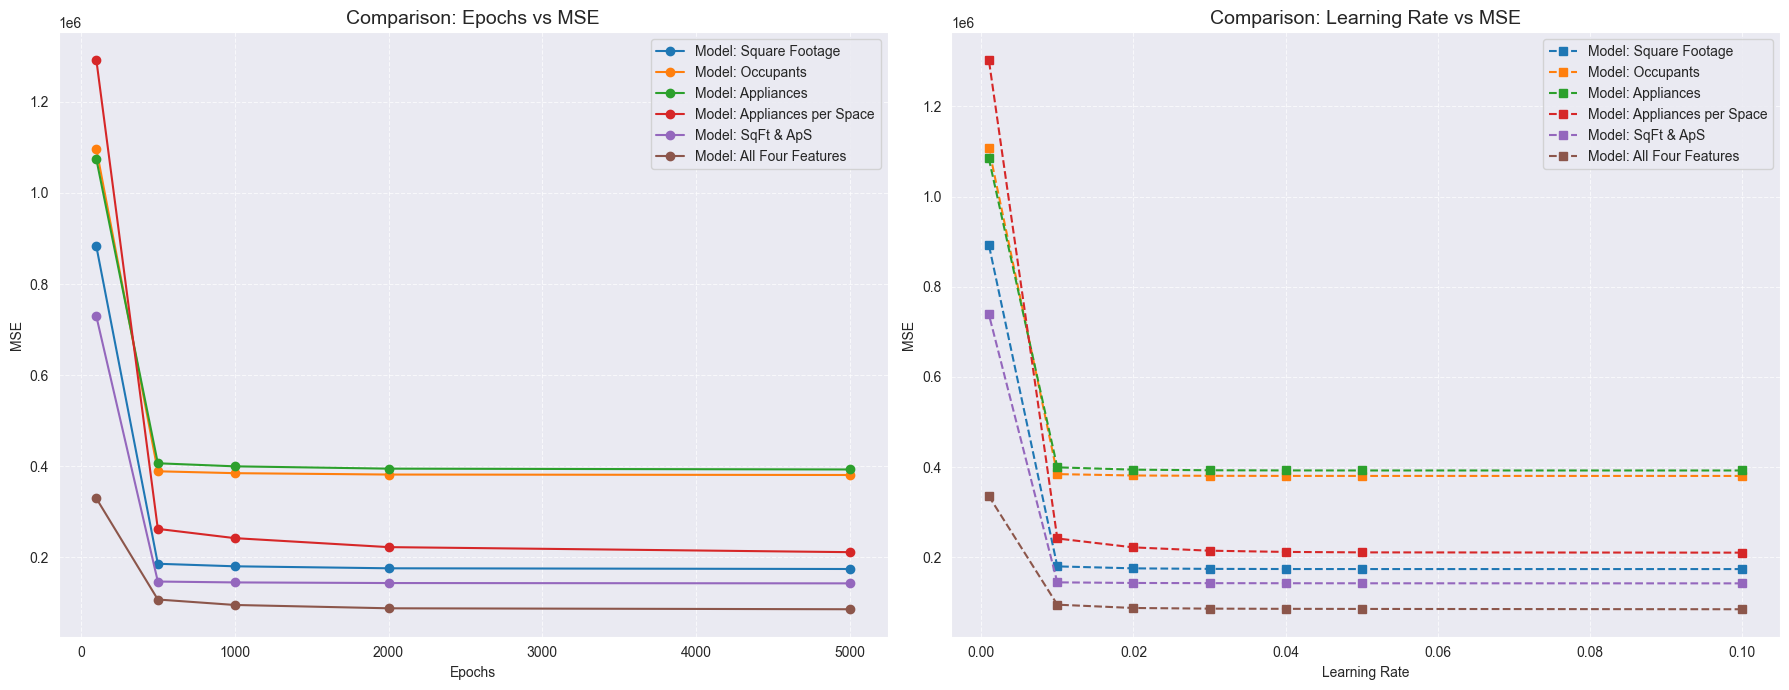

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for m in all_models:
    epochs_list = [item[0] for item in m.epochs_vs_MSE]
    mse_epochs = [item[2] for item in m.epochs_vs_MSE]

    ax1.plot(epochs_list, mse_epochs, marker='o', label=f'Model: {m.name}')

    lr_list = [item[0] for item in m.learning_rates_vs_MSE]
    mse_lr = [item[2] for item in m.learning_rates_vs_MSE]

    ax2.plot(lr_list, mse_lr, marker='s', linestyle='--', label=f'Model: {m.name}')

ax1.set_title('Comparison: Epochs vs MSE', fontsize=14)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

ax2.set_title('Comparison: Learning Rate vs MSE', fontsize=14)
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('MSE')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

#### Ruslts Summary

In [19]:
for m in all_models:
    print(f"\n" + "="*50)
    print(f"MODEL: {m.name.upper()}")
    print(f"Features Indices: {m.feature_indices}")
    print("="*50)

    print(f"{'Learning Rate':<15} | {'Epochs (Fixed)':<15} | {'MSE':<15}")
    print("-" * 48)
    for lr, W, E in m.learning_rates_vs_MSE:
        print(f"{lr:<15} | {'1000':<15} | {E:<15.6f}")

    print("."*30)

    print(f"{'Epochs':<15} | {'LR (Fixed)':<15} | {'MSE':<15}")
    print("-" * 48)
    for ep, W, E in m.epochs_vs_MSE:
        print(f"{ep:<15} | {'0.01':<15} | {E:<15.6f}")

    print("\n")


MODEL: SQUARE FOOTAGE
Features Indices: [0, 1]
Learning Rate   | Epochs (Fixed)  | MSE            
------------------------------------------------
0.1             | 1000            | 173854.460199  
0.05            | 1000            | 173885.263932  
0.04            | 1000            | 173969.607576  
0.03            | 1000            | 174284.205554  
0.02            | 1000            | 175456.625732  
0.01            | 1000            | 179822.135185  
0.001           | 1000            | 893308.463758  
..............................
Epochs          | LR (Fixed)      | MSE            
------------------------------------------------
100             | 0.01            | 883100.814359  
500             | 0.01            | 185391.491613  
1000            | 0.01            | 179822.135185  
2000            | 0.01            | 175458.010670  
5000            | 0.01            | 173885.531954  



MODEL: OCCUPANTS
Features Indices: [0, 2]
Learning Rate   | Epochs (Fixed)  | MSE           

In [20]:
summary_data = []

for m in all_models:
    best_mse_epoch = min([item[2] for item in m.epochs_vs_MSE])
    best_mse_lr = min([item[2] for item in m.learning_rates_vs_MSE])

    summary_data.append({
        "Model Name": m.name,
        "Features Used": str(m.feature_indices),
        "Best MSE (Epochs)": round(best_mse_epoch, 4),
        "Best MSE (LR)": round(best_mse_lr, 4),
        "Min MSE Overall": round(min(best_mse_epoch, best_mse_lr), 4)
    })

df_summary = pd.DataFrame(summary_data)

print("======= Models Performance Summary =======")
print(df_summary.to_string())

======= Models Performance Summary =======
             Model Name    Features Used  Best MSE (Epochs)  Best MSE (LR)  Min MSE Overall
0        Square Footage           [0, 1]        173885.5320    173854.4602      173854.4602
1             Occupants           [0, 2]        380441.1523    380426.5710      380426.5710
2            Appliances           [0, 3]        392563.2094    392531.4301      392531.4301
3  Appliances per Space           [0, 5]        210890.7788    210296.9324      210296.9324
4            SqFt & ApS        [0, 1, 5]        142333.4778    142163.2856      142163.2856
5     All Four Features  [0, 1, 2, 3, 5]         85458.0967     84751.1739       84751.1739


#### Best Models Visulaizations

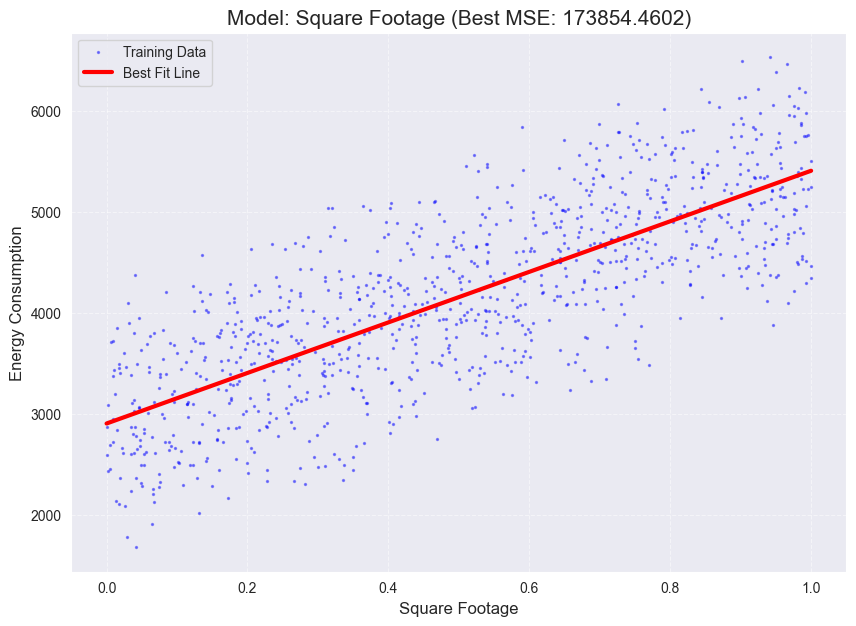

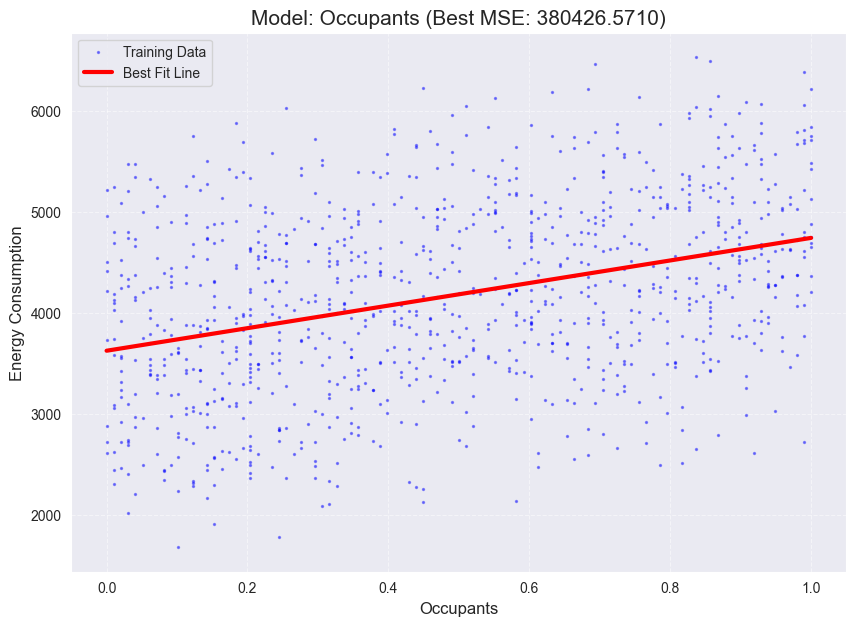

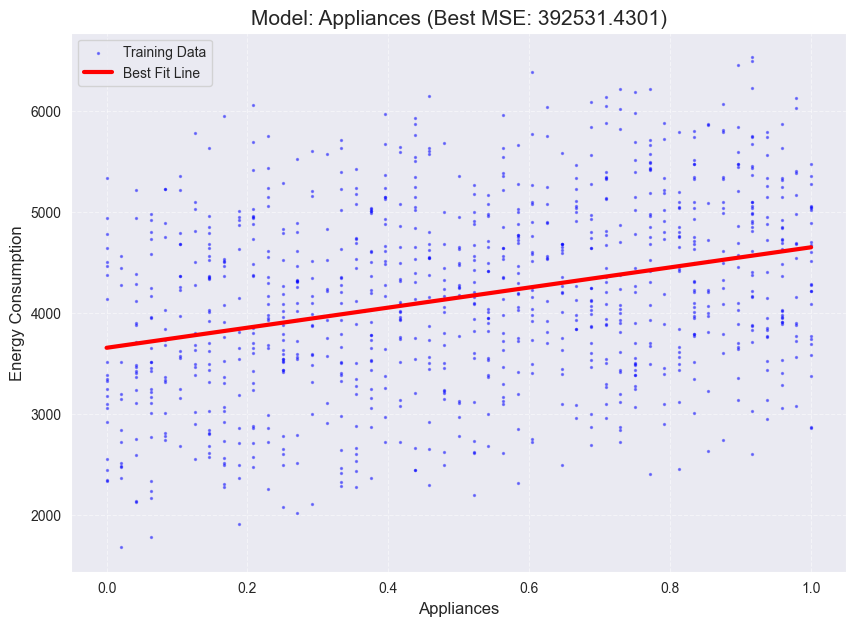

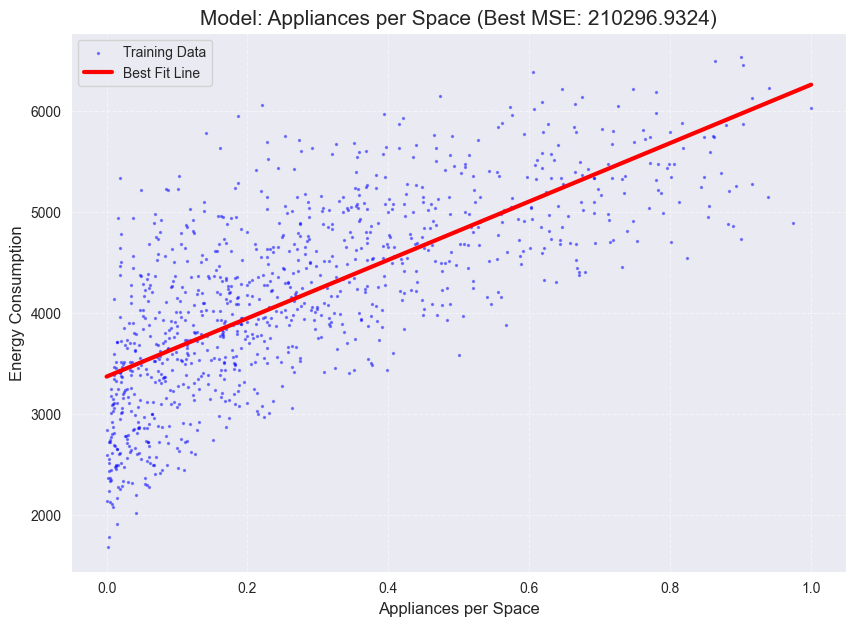

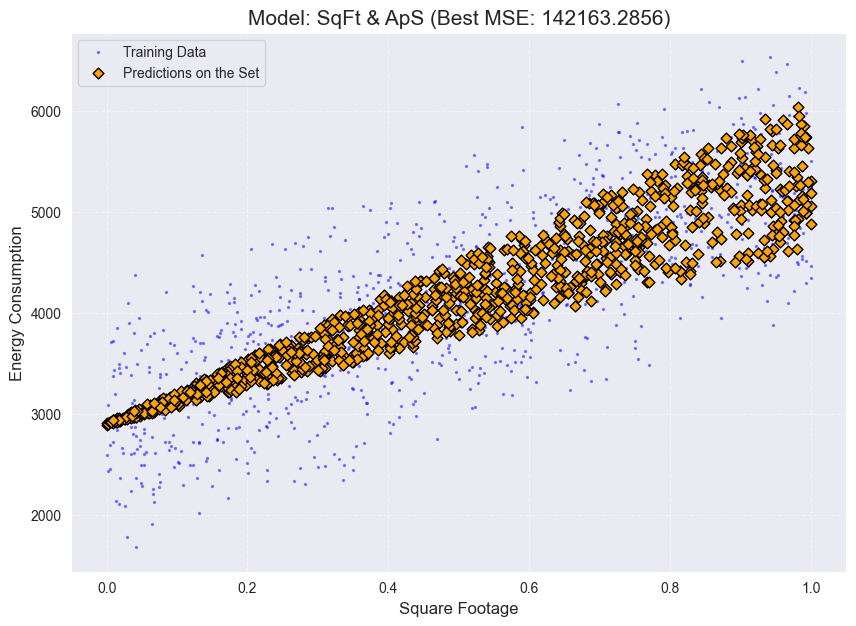

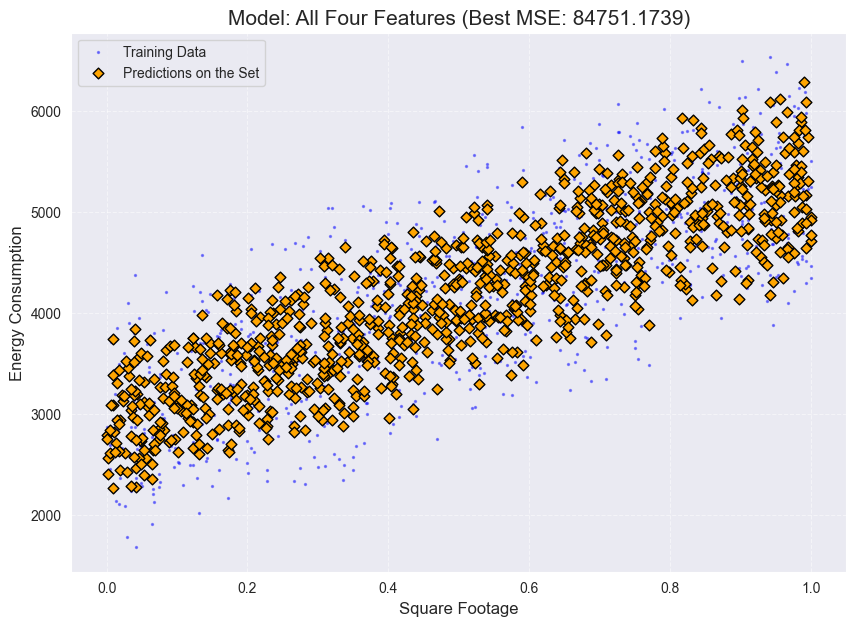

In [21]:
best_models_list = []

for m in all_models:
    all_trials = m.learning_rates_vs_MSE + m.epochs_vs_MSE
    best_trial = min(all_trials, key=lambda x: x[2])

    best_models_list.append({
        "name": m.name,
        "indices": m.feature_indices,
        "best_weights": best_trial[1],
        "best_mse": best_trial[2]
    })

feature_names = ["Bias", "Square Footage", "Occupants", "Appliances", "Unknown", "Appliances per Space"]

for res in best_models_list:
    plt.figure(figsize=(10, 7))

    display_feat_idx = 1 if 1 in res['indices'] else res['indices'][1]
    x_axis_label = feature_names[display_feat_idx]

    x_vals_actual = X_data[:, display_feat_idx - 1]

    plt.scatter(x_vals_actual, Y_data, color='blue', s=8, alpha=0.4, label='Training Data', marker='.')

    X_subset = X_with_bias[:, res['indices']]
    y_predictions = predict(X_subset, res['best_weights'])

    if len(res['indices']) == 2:
        x_min, x_max = x_vals_actual.min(), x_vals_actual.max()
        x_line = np.array([x_min, x_max])
        # حساب نقاط الخط (y = w0 + w1*x)
        y_line = res['best_weights'][0] + res['best_weights'][1] * x_line

        plt.plot(x_line, y_line, color='red', linewidth=3, label='Best Fit Line')

    else:
        plt.scatter(x_vals_actual, y_predictions,
                    color='orange', edgecolors='black', s=30, marker='D',
                    label='Predictions on the Set')

    plt.title(f"Model: {res['name']} (Best MSE: {res['best_mse']:.4f})", fontsize=15)
    plt.xlabel(x_axis_label, fontsize=12)
    plt.ylabel("Energy Consumption", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()